# 04 · GradCAM — Model Interpretability

Applies Gradient-weighted Class Activation Mapping (Grad-CAM) to the trained ECGResNet
to visualize which regions of each ECG beat drive the model's predictions.

* Hooks registered on the last ResBlock to capture gradients and activations
* Saliency map interpolated back to the original 500-sample beat length
* 3 sample beats visualized per class (N, R, V)

Requires: `ecg_resnet_best.pth`, `X_test_pi.npy`, `y_test_pi.npy`

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.preprocessing import LabelEncoder

# ── Reload model architecture ──────────────────────────────────────────────
class ResBlock(nn.Module):
    def __init__(self, channels, kernel_size=7):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size, padding=kernel_size//2),
            nn.BatchNorm1d(channels),
            nn.ReLU(),
            nn.Conv1d(channels, channels, kernel_size, padding=kernel_size//2),
            nn.BatchNorm1d(channels)
        )
        self.relu = nn.ReLU()
    def forward(self, x):
        return self.relu(x + self.conv(x))

class ECGResNet(nn.Module):
    def __init__(self, num_classes=2, in_channels=2):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=15, padding=7),
            nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2)
        )
        self.blocks = nn.Sequential(
            ResBlock(64), nn.MaxPool1d(2),
            ResBlock(64), nn.MaxPool1d(2),
            ResBlock(64)
        )
        self.pool       = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(64, 64),
            nn.ReLU(), nn.Dropout(0.4), nn.Linear(64, num_classes)
        )
    def forward(self, x):
        x = self.stem(x)
        x = self.blocks(x)
        x = self.pool(x)
        return self.classifier(x)
    def forward_features(self, x):
        x = self.stem(x)
        x = self.blocks(x)
        return x

device = torch.device('cuda')
model  = ECGResNet(num_classes=2, in_channels=2).to(device)
model.load_state_dict(torch.load('ecg_resnet_best.pth'))
model.eval()

# ── Label encoder ──────────────────────────────────────────────────────────
le = LabelEncoder()
le.fit(['N', 'V'])

# ── Load test data ─────────────────────────────────────────────────────────
X_test     = np.load('X_test_pi.npy')
y_test_raw = np.load('y_test_pi.npy')

le_old = LabelEncoder()
le_old.fit(['A', 'L', 'N', 'R', 'V'])
y_test_letters = le_old.inverse_transform(y_test_raw)

mask   = np.array([l in {'N', 'V'} for l in y_test_letters])
X_test = X_test[mask]
y_test = y_test_letters[mask]

# Normalize
mu  = X_test.mean(axis=-1, keepdims=True)
std = X_test.std(axis=-1,  keepdims=True) + 1e-8
X_test = (X_test - mu) / std

print(f"Test samples: {len(X_test)}")
print("Model loaded. Ready for Grad-CAM.")

Test samples: 24895
Model loaded. Ready for Grad-CAM.


In [2]:
# ── Grad-CAM for 1D ECG ────────────────────────────────────────────────────
def gradcam(model, x_input, target_class, device):
    """
    x_input: numpy array (2, 500)
    Returns: saliency map normalized to [0,1] of shape (500,)
    """
    model.eval()
    x = torch.tensor(x_input[np.newaxis], requires_grad=False).to(device)

    gradients = []
    activations = []

    def forward_hook(module, input, output):
        activations.append(output)

    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    # Hook on last ResBlock
    last_block = model.blocks[-1]
    fh = last_block.register_forward_hook(forward_hook)
    bh = last_block.register_full_backward_hook(backward_hook)

    # Forward
    features = model.forward_features(x)
    logits   = model.classifier(model.pool(features))

    # Backward on target class
    model.zero_grad()
    logits[0, target_class].backward()

    fh.remove()
    bh.remove()

    # Compute Grad-CAM
    grads = gradients[0].squeeze(0)        # (64, T)
    acts  = activations[0].squeeze(0)      # (64, T)
    weights = grads.mean(dim=-1)           # (64,)
    cam = (weights[:, None] * acts).sum(dim=0)  # (T,)
    cam = torch.relu(cam).cpu().detach().numpy()

    # Upsample to original signal length
    cam = np.interp(
        np.linspace(0, len(cam), x_input.shape[-1]),
        np.arange(len(cam)), cam
    )

    # Normalize
    if cam.max() > 0:
        cam = cam / cam.max()
    return cam

print("Grad-CAM function defined.")

Grad-CAM function defined.


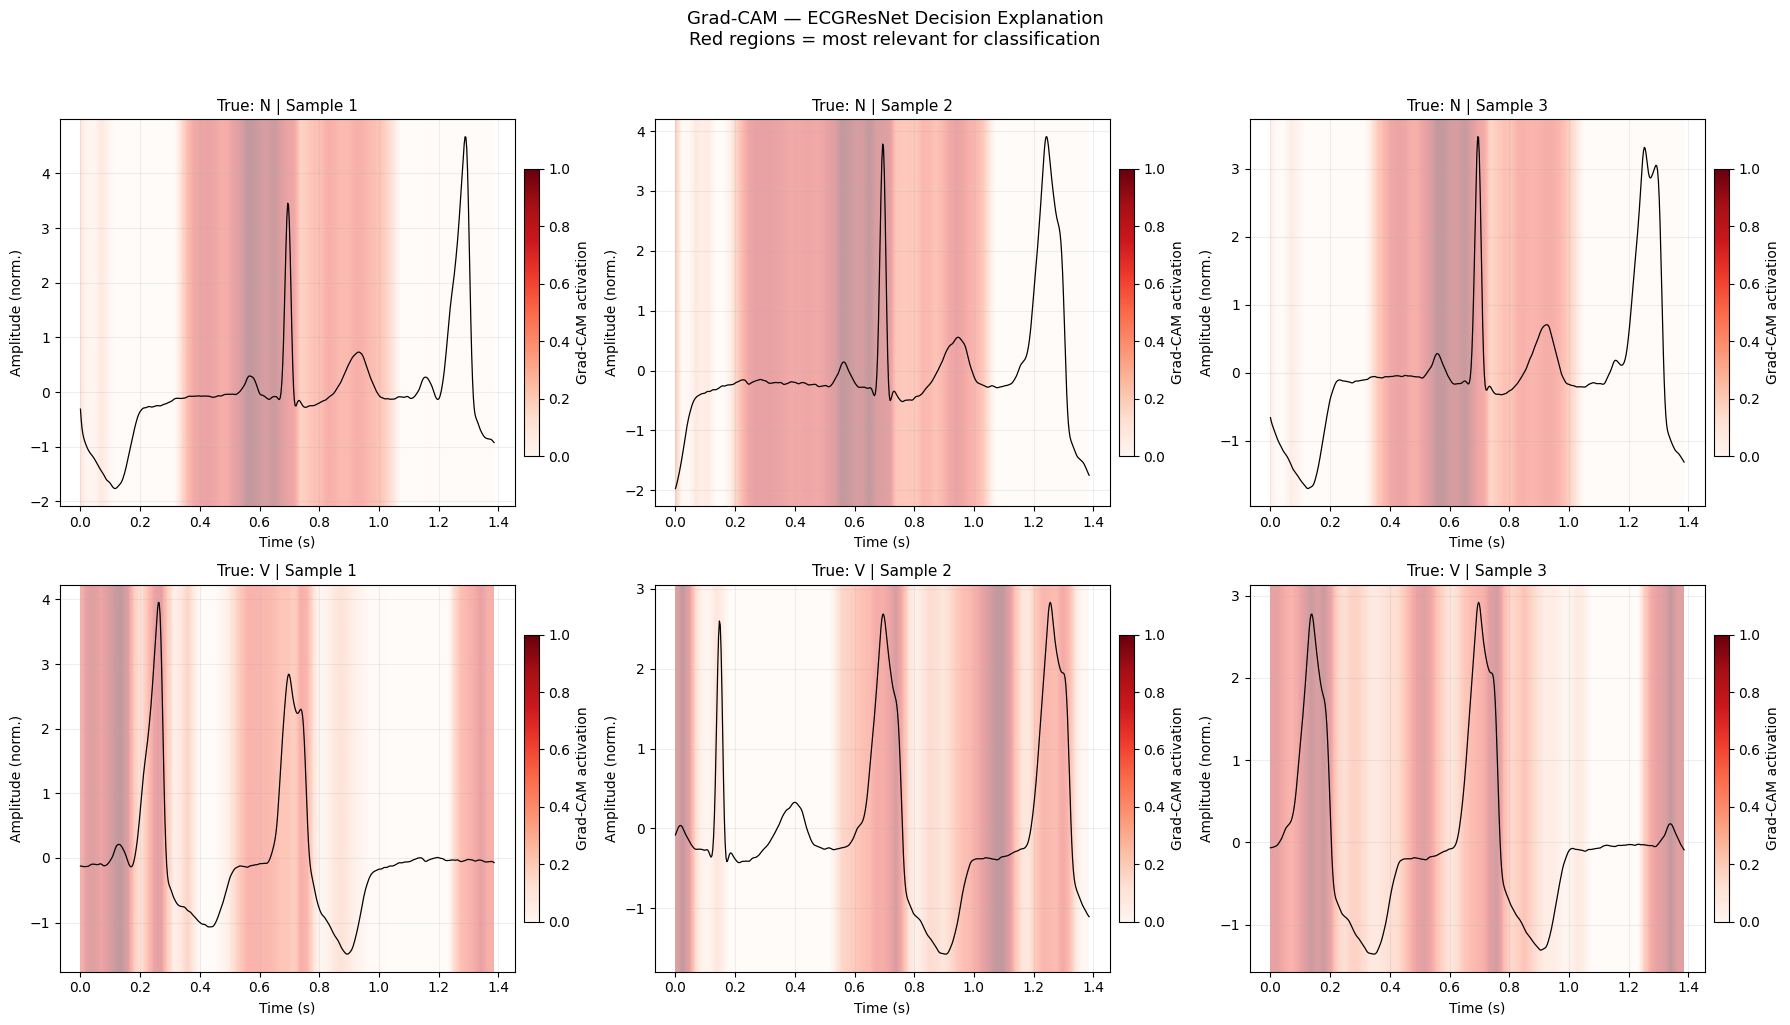

Saved: gradcam_visualization.png


In [3]:
# ── Visualize Grad-CAM on sample beats ────────────────────────────────────
def plot_gradcam(model, X, y, le, device, n_samples=3):
    class_names = list(le.classes_)
    fig, axes = plt.subplots(len(class_names), n_samples,
                             figsize=(18, 5 * len(class_names)))

    for row, cls_name in enumerate(class_names):
        cls_idx  = le.transform([cls_name])[0]
        cls_mask = np.where(y == cls_name)[0]
        samples  = cls_mask[:n_samples]

        for col, idx in enumerate(samples):
            x_input = X[idx]                    # (2, 500)
            signal  = x_input[0]                # Lead I
            t       = np.arange(len(signal)) / 360  # time in seconds

            cam = gradcam(model, x_input, target_class=cls_idx, device=device)

            ax = axes[row, col]

            # Background heatmap
            for i in range(len(t) - 1):
                ax.axvspan(t[i], t[i+1], alpha=0.4,
                           color=cm.Reds(cam[i]), linewidth=0)

            # ECG signal
            ax.plot(t, signal, color='black', linewidth=0.9)

            # Colorbar
            sm = plt.cm.ScalarMappable(cmap='Reds',
                                        norm=plt.Normalize(vmin=0, vmax=1))
            sm.set_array([])
            plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02,
                         label='Grad-CAM activation')

            ax.set_title(f"True: {cls_name} | Sample {col+1}", fontsize=11)
            ax.set_xlabel("Time (s)")
            ax.set_ylabel("Amplitude (norm.)")
            ax.grid(alpha=0.2)

    plt.suptitle("Grad-CAM — ECGResNet Decision Explanation\n"
                 "Red regions = most relevant for classification",
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig('gradcam_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: gradcam_visualization.png")

plot_gradcam(model, X_test, y_test, le, device, n_samples=3)